In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import json
import glob
import pandas as pd
import json
from pathlib import Path

In [ ]:
import pandas as pd
import json

# 1. read CSV file
try:
    df_test = pd.read_csv("test_set_me.csv", encoding='utf-8')
except UnicodeDecodeError:
    try:
        df_test = pd.read_csv("test_set_me.csv", encoding='gbk')
        print("using GBK CSV")
    except:
        df_test = pd.read_csv("test_set_me.csv", encoding='latin1')
        print("using Latin1 CSV")

print(df_test.columns.tolist())
question_to_labels = {}
for _, row in df_test.iterrows():
    question = row["question"]
    clarity_label = row["clarity_label"] 
    evasion_label = row["Label"]
    question_to_labels[question] = {
            "clarity_label": clarity_label,
            "evasion_label": evasion_label
        }

updated_count = 0
not_found_ids = []

jsonl_file_path = "/raid/jiawen/proj_master/HF_data/runningdata/test_results_full.jsonl"
output_file_path = "test_results_full_updated.jsonl"

updated_records = []

with open(jsonl_file_path, "r", encoding='utf-8') as infile:
    for line_num, line in enumerate(infile, 1):
        data = json.loads(line.strip())
        
        current_question = data.get("question")
        
        if current_question in question_to_labels:
            data["clarity_label"] = question_to_labels[current_question]["clarity_label"]
            data["evasion_label"] = question_to_labels[current_question]["evasion_label"]
            updated_count += 1
        else:
            record_id = data.get("id", f"line_{line_num}")
            not_found_ids.append(record_id)
        
        updated_records.append(data)

with open(output_file_path, "w", encoding='utf-8') as outfile:
    for record in updated_records:
        outfile.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"finished")
print(f"not found number: {len(not_found_ids)}")
print(f"update ID list: {not_found_ids}")


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#multiagent clarity and evasion based
mapping_9_to_3 = {
    0:0, 
    1:1,
    2:1,
    3:1,
    4:1,
    5:1,
    6:2,
    7:2,
    8:2,
    -2:-2
}

mapping_3_to_3 = {0:0, 1:1, 2:2, -2:-2}
mapping_9_to_9 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, -2: -2}
mapping_3labels_withnames = {'Clear Reply': 0, 'Ambivalent': 1, 'Clear Non-Reply': 2}
mapping_9labels_withnames = {'Explicit': 0, 'Implicit': 1, 'Dodging': 2, 'Deflection': 3, 'Partial/half-answer': 4, 'General': 5, 'Declining to answer': 6, 'Claims ignorance': 7, 'Clarification': 8}

In [ ]:

import glob
import os

files = glob.glob("/raid/jiawen/proj_master/**/debate_full_False_deepseek-r1_32b_result_0point75_3.jsonl", recursive=True)
for f in files:
    print(f)

/raid/jiawen/proj_master/LLM/sinble_agent_75temp/clarity_based/debate_full_False_deepseek-r1_32b_result_0point75_3.jsonl
/raid/jiawen/proj_master/LLM/Multi_agent/role_play/debate_full_False_deepseek-r1_32b_result_0point75_3.jsonl


In [28]:
def get_file (filepath):
    with open (filepath, 'r', encoding='utf-8') as f:
        for line in f:
            k = line.strip()
        print(k)


full = get_file('/raid/jiawen/proj_master/LLM/sinble_agent_75temp/clarity_based/debate_full_False_deepseek-r1_32b_result_0point75_3.jsonl')
print(full)


{"id": 106, "label": 1, "prediction": {"Taxonomy_code": 1, "final_certainty": 85}, "judge_thinking": "Okay, so I need to figure out the final verdict for this question. Let me start by understanding the context. The question is about why the President continued to claim a relationship between Saddam Hussein, Zarqawi, and Al Qaida even after a Senate report said there was no link. The President's answer explains that he was talking about Saddam being a state sponsor of terror and Zarqawi's presence in Iraq, but he never said there was an operational relationship. He emphasizes that Saddam was dangerous and that's why he was removed.\n\nNow, looking at the expert analyses. All three experts—Political, Economist, and Psychologist—gave Taxonomy_code 1, which is Ambivalent. Their reasons are similar: the President's answer clarifies that he didn't claim an operational relationship but doesn't explain why he kept making those statements after the report came out. So, the answer is incomplete

In [ ]:
pattern_zero = '/raid/jiawen/proj_master/LLM/zero_shot/*_based/*deepseek-r1*.jsonl'  
pattern_few = '/raid/jiawen/proj_master/LLM/few_shot/*_based/*deepseek-r1*.jsonl'  
pattern_sin_0 = '/raid/jiawen/proj_master/LLM/Multi_agent/*_based/debate*.jsonl'  
pattern_sin_75 = '/raid/jiawen/proj_master/LLM/sinble_agent_75temp/*_based/debate*.jsonl'  
files = glob.glob(pattern_sin_75)
def check_ids_in_file(file_path, expected_ids=set(range(308))):  # 0-307
    ids_in_file = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line.strip())
            if 'id' in data:
                ids_in_file.add(data['id'])
    
    missing_ids = expected_ids - ids_in_file
    return missing_ids

n = 0
for i in files:
    file = check_ids_in_file(i)
    print(file)


set()
set()
set()
set()
set()
set()


In [ ]:
import re, csv
'''

def check_ids_in_file(input_file_path, first):  
        lines = 0
        filename = input_file_path.split('/')[-1]
        #print("This is ", filename)
        match = re.search(r'(multi|all|full)_(True|False)', filename)
        match2 = re.search(r'r1_([\d.]+)', filename)
        #match2 = re.search(r'0point75_(\d+)', filename)

        if match and match2:
                input_type = match.group(1)
                experiment = match.group(2)
                experiment_type = "evasion_based" if experiment == "True" else "clarity_based"
                model = float(match2.group(1))
                #run_type = "Third" if run == 3 else ("Second" if run == 2 else ("First" if run == 1 else "Unknown"))
        else:
                print("Error")
        out_file = f"zeroshot.csv"
        with open(input_file_path, 'r', encoding='utf-8') as f,\
        open(out_file, 'a', encoding = 'utf-8', newline = '') as c:
                csv_writer = csv.writer(c)
                if first:
                        name = ['id', 'input_type', 'experiment_type', 'model','true_label', 'predicted_label']
                        csv_writer.writerow(name)

                for line in f:
                       data = json.loads(line.strip())
                       
                       id_n = data['id']
                       true_label = data['label']
                       #political_label= data["agents"]["political"]["Taxonomy_code"]
                       #economist_label = data["agents"]["economist"]["Taxonomy_code"]
                       #psychology_label = data["agents"]["psychologist"]["Taxonomy_code"]
                       predicted_label = data["prediction"]["Taxonomy_code"]
                       writing_data = [id_n,input_type, experiment_type, model, true_label, predicted_label]
                       csv_writer.writerow(writing_data)
                       lines +=1
        return lines


pattern = '/raid/jiawen/proj_master/LLM/few_shot/*_based/*deepseek*.jsonl'
files = glob.glob(pattern)  

total_li = 0
for idx, i in enumerate(files):
        first_file = (idx == 0)
        print(i)
        count = check_ids_in_file(i,first_file)
        total_li += count
print(total_li)

'''

In [ ]:
import pandas as pd

def check_ids_in_file(file_path, expected_ids=set(range(308))):
    df = pd.read_csv(file_path)
    ids_in_file = set(df['id'])
    
    missing_ids = expected_ids - ids_in_file
    return missing_ids

check_ids_in_file("single_4agent_result_0temp.csv")

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from itertools import combinations


df = pd.read_csv("single_4agent_result_0temp.csv")
raters = ['political_label', 'economist_label', 'psychology_label', 'judge_label']
experiment_types = df['experiment_type'].unique()
for exp in experiment_types:
    sub = df[df['experiment_type'] == exp].copy()
    if exp == "evasion_based":
        for r in raters:
            sub[r] = sub[r].map(mapping_9_to_3)
    print(f"\n=== {exp} ===")
    for r1, r2 in combinations(raters, 2):
        print(f"{r1} vs {r2}: {cohen_kappa_score(sub[r1], sub[r2]):.4f}")
    print(f"Fleiss κ: {fleiss_kappa(aggregate_raters(sub[raters].values)[0]):.4f}")


=== evasion_based ===
political_label vs economist_label: 0.6572
political_label vs psychology_label: 0.6845
political_label vs judge_label: 0.7595
economist_label vs psychology_label: 0.7128
economist_label vs judge_label: 0.7979
psychology_label vs judge_label: 0.8459
Fleiss κ: 0.7438

=== clarity_based ===
political_label vs economist_label: 0.5564
political_label vs psychology_label: 0.6016
political_label vs judge_label: 0.6977
economist_label vs psychology_label: 0.6042
economist_label vs judge_label: 0.7358
psychology_label vs judge_label: 0.7843
Fleiss κ: 0.6652


In [3]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report
df_zero = pd.read_csv('zeroshot.csv')
df_fewshot = pd.read_csv('fewshot.csv')
single4_result_0tem = pd.read_csv('single_4agent_result_0temp.csv')
single4_result_75tem = pd.read_csv('single_4agent_result_75temp.csv')

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
input_name_map = {
        'all': 'Type A',
        'multi': 'Type B',
        'full': 'Type Original'
    }

def safe_int(val, default=-2):
    try:
        return int(val)
    except (ValueError, TypeError):
        return default


def get_classify_report(df): 
    class_rows = []
    macro_rows = []
    grouped = df.groupby(['experiment_type', 'run_type'])

    for (exp_type, run_type), group in grouped:
        
        if exp_type == 'evasion_based':
            y_true = [mapping_9_to_3.get(l) for l in group['true_label']]
            y_pred_rwa = [mapping_9_to_3.get(safe_int(l), 999) for l in group['judge_label']]
            y_pred = [999 if p in (-1, -2, 999) else p for p in y_pred_rwa]
            label_ids   = [0, 1, 2]
            label_names = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
            #label_ids   = [0, 1, 2,3,4,5,6,7,8]
            #label_names = list(mapping_9labels_withnames.keys())
            #label_names = list(mapping_9labels_withnames.keys())
            #label_ids = list(mapping_9labels_withnames.values())
        
        else:
            y_true = [mapping_3_to_3.get(l) for l in group['true_label']]
            y_pred = [mapping_3_to_3.get(safe_int(l), 999) for l in group['judge_label']]
            label_ids   = [0, 1, 2]
            label_names = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
            
        report = classification_report(
            y_true,
            y_pred,
            labels=label_ids,
            target_names=label_names,  
            output_dict=True,
            zero_division=0
        )

        run_type_display = input_name_map.get(run_type)
        print("This is ", run_type, exp_type)
        print(report)
        cm = confusion_matrix(y_true, y_pred, labels=label_ids, normalize='true')
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names).plot(cmap='Blues', values_format='.0%')  
        disp.ax_.set_xticklabels(label_names, rotation=45, ha='right')
        plt.title(f"{exp_type} - {run_type}")
        plt.show()
    
        for cls in label_names: 
            if cls not in report:
                continue
            metrics = report[cls]
            class_rows.append({
                'experiment': exp_type,
                'run': run_type,
                'class': cls,
                'f1': metrics['f1-score']
            })
                
        macro_rows.append({
            'experiment': exp_type,
            'run': run_type,
            'accuracy':  report.get('accuracy'),
            'precision': report['macro avg']['precision'],
            'recall': report['macro avg']['recall'],
            'f1_macro': report['macro avg']['f1-score'],
            'f1_weighted': report['weighted avg']['f1-score']
        })
    return class_rows, macro_rows



This is  First clarity_based
{'Clear Reply': {'precision': 0.6236559139784946, 'recall': 0.7341772151898734, 'f1-score': 0.6744186046511628, 'support': 79.0}, 'Ambivalent': {'precision': 0.83125, 'recall': 0.6456310679611651, 'f1-score': 0.726775956284153, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.2727272727272727, 'recall': 0.6521739130434783, 'f1-score': 0.38461538461538464, 'support': 23.0}, 'accuracy': 0.6688311688311688, 'macro avg': {'precision': 0.5758777289019225, 'recall': 0.6773273987315056, 'f1-score': 0.5952699818502335, 'support': 308.0}, 'weighted avg': {'precision': 0.7362955989513907, 'recall': 0.6688311688311688, 'f1-score': 0.6877956837926338, 'support': 308.0}}


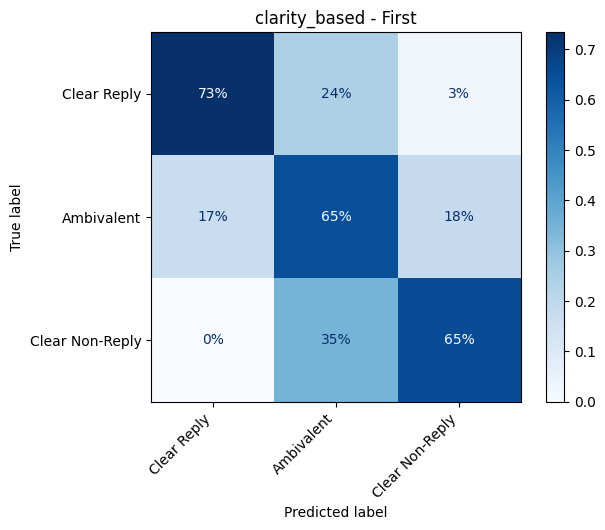

This is  Second clarity_based
{'Clear Reply': {'precision': 0.6195652173913043, 'recall': 0.7215189873417721, 'f1-score': 0.6666666666666666, 'support': 79.0}, 'Ambivalent': {'precision': 0.8303030303030303, 'recall': 0.6650485436893204, 'f1-score': 0.738544474393531, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.27450980392156865, 'recall': 0.6086956521739131, 'f1-score': 0.3783783783783784, 'support': 23.0}, 'accuracy': 0.6753246753246753, 'macro avg': {'precision': 0.5747926838719678, 'recall': 0.6650877277350019, 'f1-score': 0.5945298398128588, 'support': 308.0}, 'weighted avg': {'precision': 0.7347461100861472, 'recall': 0.6753246753246753, 'f1-score': 0.6932127632936258, 'support': 308.0}}


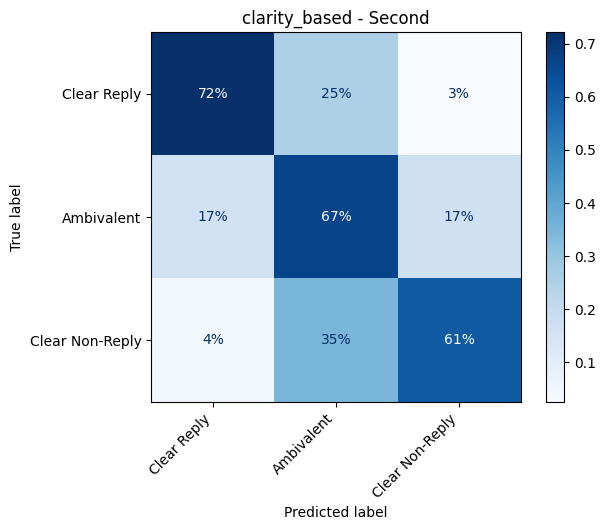

This is  Third clarity_based
{'Clear Reply': {'precision': 0.6363636363636364, 'recall': 0.7974683544303798, 'f1-score': 0.7078651685393258, 'support': 79.0}, 'Ambivalent': {'precision': 0.8571428571428571, 'recall': 0.6407766990291263, 'f1-score': 0.7333333333333333, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.2909090909090909, 'recall': 0.6956521739130435, 'f1-score': 0.41025641025641024, 'support': 23.0}, 'accuracy': 0.685064935064935, 'macro avg': {'precision': 0.5948051948051948, 'recall': 0.7112990757908498, 'f1-score': 0.6171516373763564, 'support': 308.0}, 'weighted avg': {'precision': 0.7582307303086524, 'recall': 0.685064935064935, 'f1-score': 0.7026750403154898, 'support': 308.0}}


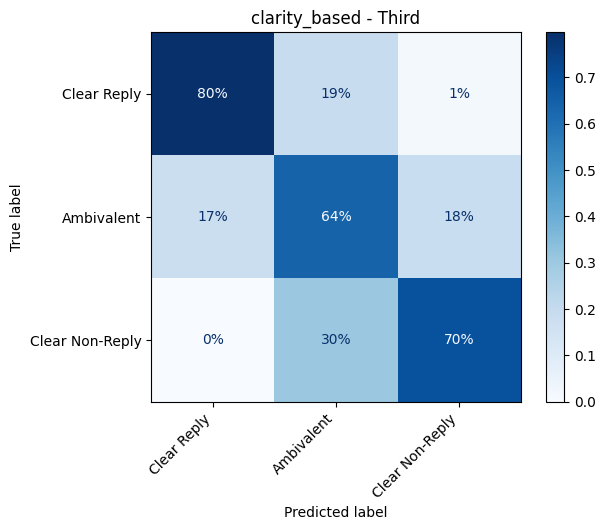

This is  First evasion_based
{'Clear Reply': {'precision': 0.5929203539823009, 'recall': 0.8481012658227848, 'f1-score': 0.6979166666666666, 'support': 79.0}, 'Ambivalent': {'precision': 0.8971428571428571, 'recall': 0.7621359223300971, 'f1-score': 0.8241469816272966, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.85, 'recall': 0.7391304347826086, 'f1-score': 0.7906976744186046, 'support': 23.0}, 'accuracy': 0.7824675324675324, 'macro avg': {'precision': 0.7800210703750526, 'recall': 0.7831225409784969, 'f1-score': 0.7709204409041893, 'support': 308.0}, 'weighted avg': {'precision': 0.8155913523897089, 'recall': 0.7824675324675324, 'f1-score': 0.7892718876412911, 'support': 308.0}}


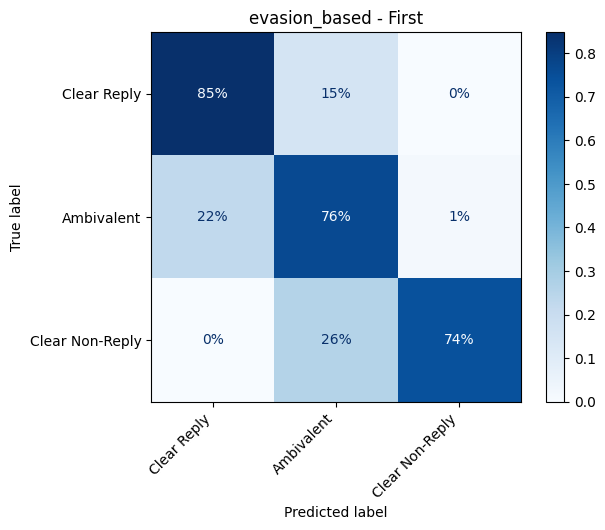

This is  Second evasion_based
{'Clear Reply': {'precision': 0.5929203539823009, 'recall': 0.8481012658227848, 'f1-score': 0.6979166666666666, 'support': 79.0}, 'Ambivalent': {'precision': 0.8908045977011494, 'recall': 0.7524271844660194, 'f1-score': 0.8157894736842105, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.7142857142857143, 'recall': 0.6521739130434783, 'f1-score': 0.6818181818181818, 'support': 23.0}, 'accuracy': 0.7694805194805194, 'macro avg': {'precision': 0.7326702219897215, 'recall': 0.7509007877774275, 'f1-score': 0.7318414407230196, 'support': 308.0}, 'weighted avg': {'precision': 0.8012176185701623, 'recall': 0.7694805194805194, 'f1-score': 0.7755515143747799, 'support': 308.0}}


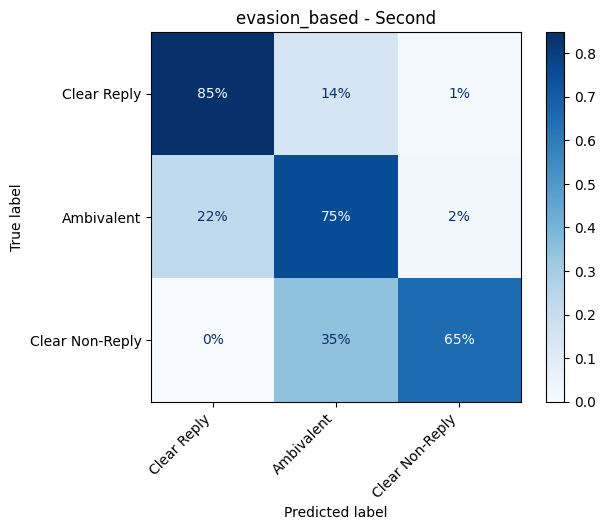

This is  Third evasion_based
{'Clear Reply': {'precision': 0.625, 'recall': 0.8860759493670886, 'f1-score': 0.7329842931937173, 'support': 79.0}, 'Ambivalent': {'precision': 0.9142857142857143, 'recall': 0.7766990291262136, 'f1-score': 0.8398950131233596, 'support': 206.0}, 'Clear Non-Reply': {'precision': 0.7619047619047619, 'recall': 0.6956521739130435, 'f1-score': 0.7272727272727273, 'support': 23.0}, 'accuracy': 0.7987012987012987, 'macro avg': {'precision': 0.767063492063492, 'recall': 0.7861423841354486, 'f1-score': 0.7667173445299348, 'support': 308.0}, 'weighted avg': {'precision': 0.8287067099567099, 'recall': 0.7987012987012987, 'f1-score': 0.8040630019252872, 'support': 308.0}}


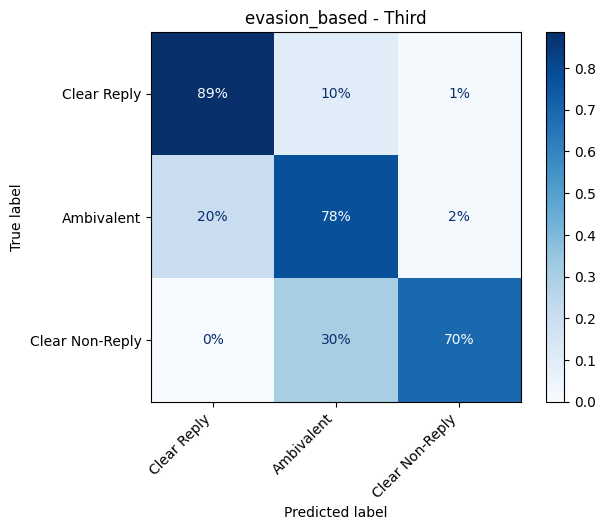

In [18]:
class_rows, macro_rows = get_classify_report(single4_result_75tem)
df_heatmap = pd.DataFrame(class_rows)
df_line = pd.DataFrame(macro_rows)

i=0, j=0, inp=Type A, exp=clarity_based
i=0, j=1, inp=Type A, exp=evasion_based


/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


i=1, j=0, inp=Type Original, exp=clarity_based
i=1, j=1, inp=Type Original, exp=evasion_based


/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


i=2, j=0, inp=Type B, exp=clarity_based


/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/raid/jiawen/.cache/virtualenvs/llm-nW7h6vOu-py3.10/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


i=2, j=1, inp=Type B, exp=evasion_based


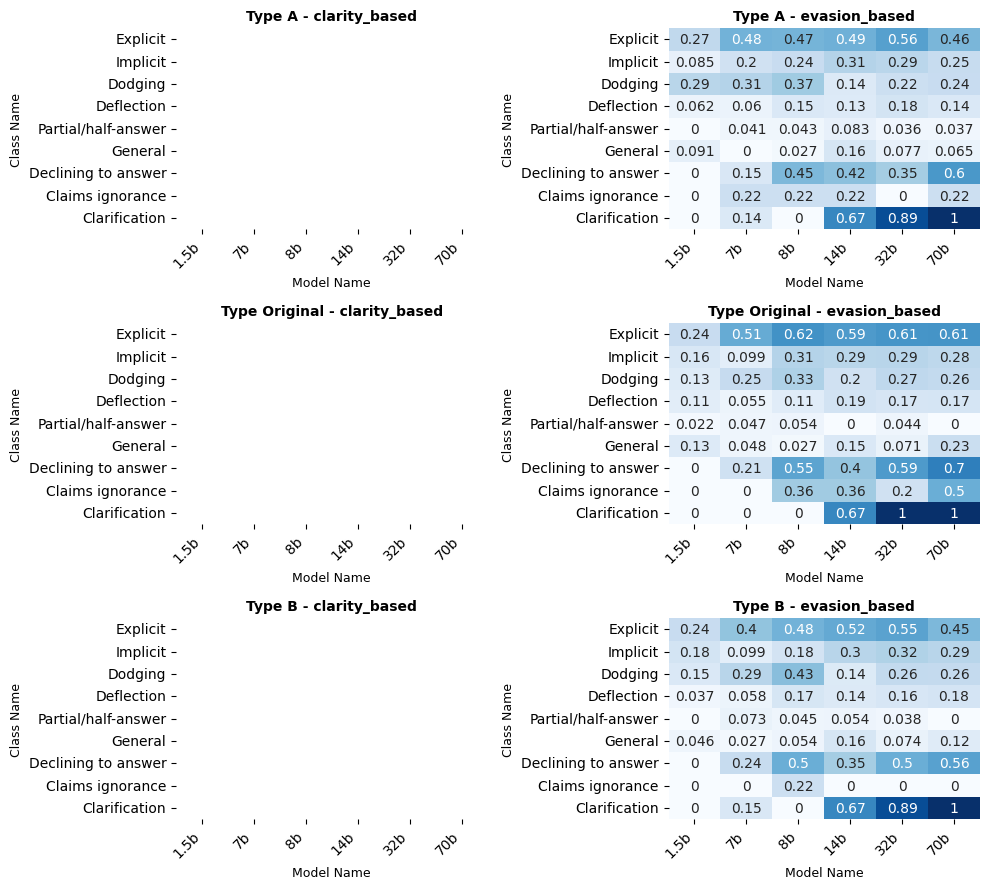

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 9))

inputs = df_heatmap['input'].unique()
experiments = df_heatmap['experiment'].unique()

df_heatmap['model'] = df_heatmap['model'].astype(str)


for i, inp in enumerate(inputs):
    for j, exp in enumerate(experiments):
        print(f"i={i}, j={j}, inp={inp}, exp={exp}")
        subset = df_heatmap[
            (df_heatmap['input'] == inp) &
            (df_heatmap['experiment'] == exp)
        ]
        
        dupes = subset[subset.duplicated(['class', 'model'], keep=False)]
        if len(dupes) > 0:
            print(f"\n{inp} | {exp}:")
            print(dupes)

        pivot = subset.pivot(
            index='class',
            columns='model',
            values='f1'
        )
        pivot.columns = [str(c).replace('.0', '') + 'b' for c in pivot.columns]
        pivot.columns = [c.replace('.0b', 'b') for c in pivot.columns]

        label_names = list(mapping_9labels_withnames.keys())

        #label_names = ['Clear Reply', 'Ambivalent', 'Clear Non-Reply']
        pivot = pivot.reindex(label_names)

        model_order = sorted(pivot.columns, key=lambda x: float(x.replace('b', '')))
        pivot = pivot[model_order]
        
        sns.heatmap(pivot, annot=True, ax=axes[i, j], cbar=False, cmap="Blues")
        
        # set title input and experiment info
        axes[i, j].set_title(f"{inp} - {exp}", fontsize=10, fontweight='bold')
        
        # set X axis
        axes[i, j].set_xlabel('Model Name', fontsize=9)
        
        # set Y axis
        axes[i, j].set_ylabel('Class Name', fontsize=9)
        
        axes[i, j].set_xticklabels(axes[i, j].get_xticklabels(), rotation=45, ha='right')
        

plt.tight_layout()
plt.show()

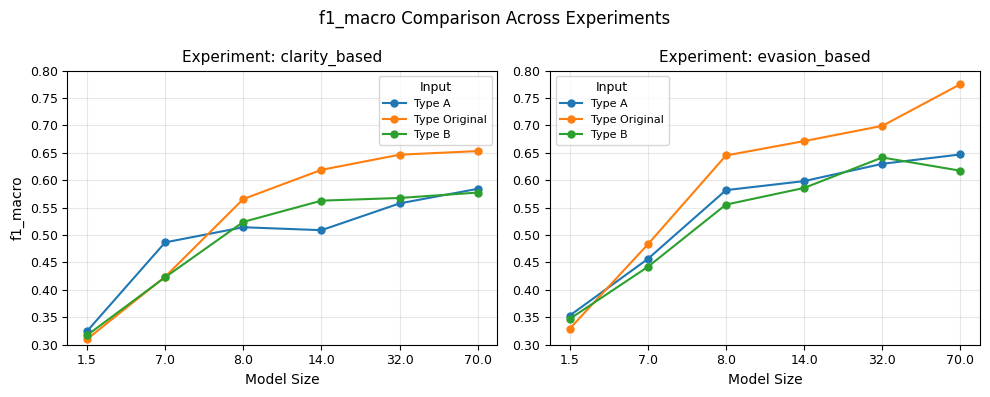

In [ ]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

inputs = df_line['input'].unique()
experiments = df_line['experiment'].unique()

df_line['model'] = df_line['model'].astype(str)

colors = {'input_a': '#2196F3', 'input_b': '#FF5722', 'input_c': '#4CAF50'}

y_min = df_line['f1_macro'].min() - 0.02
y_max = df_line['f1_macro'].max() + 0.02

for j, exp in enumerate(experiments):
    ax = axes[j]

    for inp in inputs:
        subset = df_line[
            (df_line['input'] == inp) &
            (df_line['experiment'] == exp) 
        ]

        if subset.empty:
            continue

        model_order = sorted(
            subset['model'].unique(),
            key=lambda x: float(x.replace('b', ''))
        )

        subset_sorted = subset.set_index('model').loc[model_order].reset_index()

        ax.plot(
            subset_sorted['model'],
            subset_sorted['f1_macro'],
            marker='o', linewidth=1.5, markersize=5,
            label=inp,
            color=colors.get(inp, None)
        )

    ax.set_title(f'Experiment: {exp}', fontsize=11)
    ax.set_xlabel('Model Size', fontsize=10)
    ax.set_ylabel('f1_macro' if j == 0 else '', fontsize=10)
    ax.set_ylim(0.3, 0.8)
    ax.set_yticks(np.arange(0.3, 0.81, 0.05))    
    ax.tick_params(labelsize=9)
    ax.legend(title='Input', fontsize=8, title_fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('f1_macro Comparison Across Experiments', fontsize=12)
plt.tight_layout()
plt.savefig('lineplot.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [17]:
y_true = df['true_label']
y_pred = df['predicted_labe']
grouped = df.groupby(['experiment_type', 'strategy'])
for (exp_type, st), group in grouped:
    print(f"Experiment: {exp_type}, strategy: {st}")
    print(classification_report(group['true_label'], group['predicted_labe'], zero_division=0))



Experiment: clarity_based, strategy: v0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.62      0.80      0.70        20
           2       0.00      0.00      0.00         2

    accuracy                           0.53        30
   macro avg       0.21      0.27      0.23        30
weighted avg       0.41      0.53      0.46        30

Experiment: clarity_based, strategy: v1
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         8
           1       0.85      0.55      0.67        20
           2       0.00      0.00      0.00         2

    accuracy                           0.63        30
   macro avg       0.47      0.52      0.46        30
weighted avg       0.72      0.63      0.64        30

Experiment: clarity_based, strategy: v2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
         